# Clustering với DBSCAN

Nguồn: https://www.digitalvidya.com/blog/the-top-5-clustering-algorithms-data-scientists-should-know/
![image.png](https://imgur.com/9D6aAF2.gif)

In [8]:
import numpy as np
import matplotlib
from matplotlib import pyplot as plt

np.set_printoptions(precision=3, suppress=True)

## 1. Dữ liệu giả định
(Cùng dữ liệu giả với `03_Demo-kMeans.ipynb`)

In [9]:
np.random.seed(1)
x1,y1 = np.random.normal(loc=2,scale=1,size=50), np.random.normal(loc=5,scale=1,size=50)
x2,y2 = np.random.normal(loc=5,scale=1,size=75), np.random.normal(loc=1,scale=1,size=75)
x3,y3 = np.random.normal(loc=8,scale=1,size=100), np.random.normal(loc=7,scale=1,size=100)

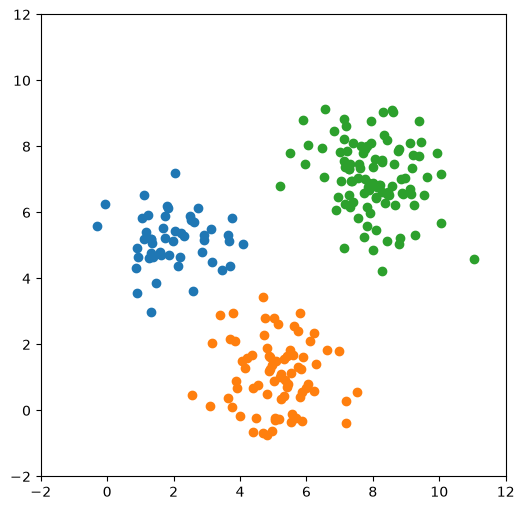

In [10]:
fig = plt.figure(figsize=(6,6))
plt.xlim([-2,12])
plt.ylim([-2,12])

plt.scatter(x1, y1)
plt.scatter(x2, y2)
plt.scatter(x3, y3)
plt.show()

### Ghép nối dữ liệu lại thành 1 tập

In [11]:
dat1 = np.stack([x1,y1]).T
dat1.shape

(50, 2)

In [12]:
dat2 = np.stack([x2,y2]).T
dat3 = np.stack([x3,y3]).T

In [13]:
dat = np.vstack([dat1, dat2, dat3])
dat.shape

(225, 2)

### Sắp ngẫu nhiên các dòng

In [14]:
np.random.seed(2)
np.random.shuffle(dat)

### Kiểm tra lại với biểu đồ scatter

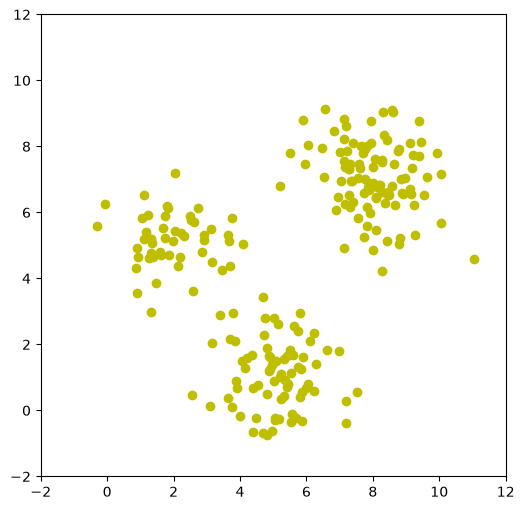

In [15]:
fig = plt.figure(figsize=(6,6))
plt.xlim([-2,12])
plt.ylim([-2,12])

plt.scatter(dat[:,0], dat[:,1], color='y')
plt.show()

## 2. Thực hiện phân cụm bằng DBSCAN

**=== Import lớp DBSCAN từ thư viện sklearn ===**

In [16]:
from sklearn.cluster import DBSCAN

### 2.1. Khởi tạo model và fit vào dữ liệu

In [17]:
# Giả sử chọn epsilon = 1, minPoints = 5
# ???
model = DBSCAN(eps=1, min_samples=5)

**=== Thực hiện fit vào dữ liệu ===**

In [18]:
# ???
model.fit(dat)

,"eps eps: float, default=0.5The maximum distance between two samples for one to be consideredas in the neighborhood of the other. This is not a maximum boundon the distances of points within a cluster. This is the mostimportant DBSCAN parameter to choose appropriately for your data setand distance function. Smaller values generally lead to more clusters.",1
,"min_samples min_samples: int, default=5The number of samples (or total weight) in a neighborhood for a point tobe considered as a core point. This includes the point itself. If`min_samples` is set to a higher value, DBSCAN will find denser clusters,whereas if it is set to a lower value, the found clusters will be moresparse.",5
,"metric metric: str, or callable, default='euclidean'The metric to use when calculating distance between instances in afeature array. If metric is a string or callable, it must be one ofthe options allowed by :func:`sklearn.metrics.pairwise_distances` forits metric parameter.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors for DBSCAN... versionadded:: 0.17 metric *precomputed* to accept precomputed sparse matrix.",'euclidean'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function... versionadded:: 0.19",None
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'The algorithm to be used by the NearestNeighbors moduleto compute pointwise distances and find nearest neighbors.'auto' will attempt to decide the most appropriate algorithmbased on the values passed to :meth:`fit` method.See :class:`~sklearn.neighbors.NearestNeighbors` documentation fordetails.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or cKDTree. This can affect the speedof the construction and query, as well as the memory requiredto store the tree. The optimal value dependson the nature of the problem.",30
,"p p: float, default=NoneThe power of the Minkowski metric to be used to calculate distancebetween points. If None, then ``p=2`` (equivalent to the Euclideandistance). When p=1, this is equivalent to Manhattan distance.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
Name,Type,Value
"components_ components_: ndarray of shape (n_core_samples, n_features)Copy of each core sample found by training.","ndarray[float64](206, 2)","[[ 5.96, 7.47], [ 8.96, 7.05], [ 4.7 ,-0.67], ..., [ 6.27, 1.42], [ 0.9 , 4.92], [ 7.32, 7.48]]"
"core_sample_indices_ core_sample_indices_: ndarray of shape (n_core_samples,)Indices of core samples.","ndarray[int64](206,)","[ 0, 1, 3,...,222,223,224]"


### 2.2. Kiểm tra kết quả các cluster tìm được

**=== Lấy ra nhãn các clusters ===**

In [19]:
# ???
cluster = model.labels_

In [20]:
cluster

array([ 0,  0,  2,  1,  1,  2,  0,  1,  1,  1,  1,  0,  0,  2,  2,  0,  2,
        0,  1,  2,  1,  0,  0,  2,  0,  0,  1,  1,  1,  0,  0,  2,  2,  1,
        1,  1,  0,  2,  2,  2,  2,  2,  0, -1,  0, -1,  1,  2,  0,  2,  0,
        1,  2,  0,  1,  0,  0,  1,  0,  0,  0,  1,  0,  0,  0,  0,  2,  1,
        2,  0,  0,  0, -1,  2,  2,  0,  0,  1,  0,  0,  0,  0,  0,  0,  1,
        0,  0, -1, -1,  0,  0,  2,  0,  0,  0,  0,  1,  1,  1,  0,  0,  2,
        0,  0,  0,  1,  1, -1,  0, -1,  1,  0,  1,  0,  0,  0,  1,  1,  2,
        1,  0,  0,  0,  0,  0,  0,  0,  2,  1,  1,  2,  2,  1,  0,  0,  0,
        2,  1,  0,  0,  1,  1,  2,  0,  0,  1,  0,  1,  0,  1,  1,  1,  0,
        1,  2,  1,  1,  0,  1,  2,  2,  0,  1,  0,  2,  2,  0,  1,  1,  1,
        1,  1,  1,  0,  0,  0,  0,  0,  0,  2,  2,  0,  0,  1,  1,  1,  0,
        1,  0,  2,  1,  1,  1,  0,  1,  2,  2,  1,  1,  1,  0,  2,  1,  0,
        0,  2,  1,  1,  0,  2,  1,  2,  0,  1,  0,  0,  2,  1,  1,  0,  2,
        2,  1,  2,  0])

**=== Đếm xem mỗi cluster có bao nhiêu điểm ===**

In [21]:
# ???
unique, counts = np.unique(cluster, return_counts=True)

for c, count in zip(unique, counts):
    print(f"Cụm {c}: {count} điểm")

Cụm -1: 7 điểm
Cụm 0: 98 điểm
Cụm 1: 73 điểm
Cụm 2: 47 điểm


**=== Hiển thị lên biểu đồ ===**

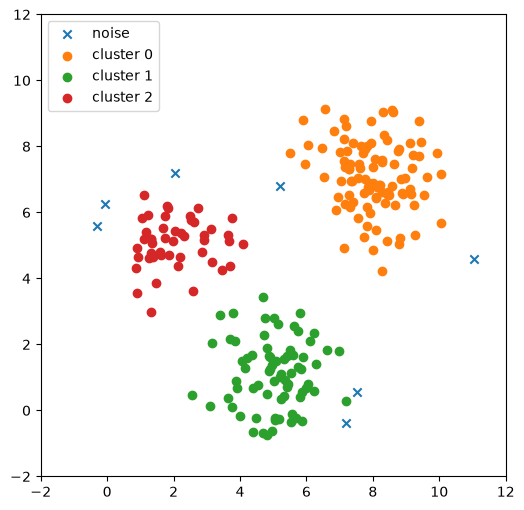

In [22]:
fig = plt.figure(figsize=(6,6))
plt.xlim([-2,12])
plt.ylim([-2,12])

# ???
for c in np.unique(cluster):
    if c == -1:
        plt.scatter(
            dat[cluster == c, 0],
            dat[cluster == c, 1],
            marker='x',
            label='noise'
        )
    else:
        plt.scatter(
            dat[cluster == c, 0],
            dat[cluster == c, 1],
            label=f'cluster {c}'
        )

plt.legend()

plt.show()

### 2.3. Tính hiệu suất phân cụm

**=== Thử tính với hàm built-in của Sklearn ===**

In [23]:
from sklearn.metrics import silhouette_score

In [24]:
# ???
silhouette = silhouette_score(dat, cluster)

print("Silhouette Score:", silhouette)

Silhouette Score: 0.639460128792222


**=== Tính lại với các cụm không chứa điểm noise ===**

In [25]:
import pandas as pd

In [26]:
# Bỏ đi các samples bị xác định là noise
# ???
mask = cluster != -1

dat2 = dat[mask]
cluster2 = cluster[mask]

In [27]:
# Tạo một list rỗng để chứa hệ số Silhouette của mỗi sample
s_list = []

for i, sample in enumerate(dat2):
    label = cluster2[i]
    
    # Lấy ra các samples khác và nhãn khác
    other_samples = np.delete(dat2, i, axis=0)
    other_labels = np.delete(cluster2, i)
    
    # Tính khoảng cách từ sample đến tất cả các other_samples
    distances = np.sqrt(np.sum((other_samples - sample) ** 2, axis=1))
    
    # Tạo dataframe với 2 cột 'distance' và 'cluster' để dùng groupby tính mean()
    df = pd.DataFrame({
        'distance': distances,
        'cluster': other_labels
    })
    
    # Lấy ra giá trị p, q tương ứng
    p = df[df['cluster'] == label]['distance'].mean()
    
    mean_distance = df.groupby('cluster')['distance'].mean()
    mean_distance = mean_distance.drop(label)
    
    q = mean_distance.min()
    
    # Tính ra hệ số Silhouette cho sample
    s = (q - p) / max(p, q)
    s_list.append(s)

In [28]:
# Tính trung bình hệ số Silhouette của tất cả các samples
# ???
silhouette = np.mean(s_list)

print("Silhouette Score:", silhouette)

Silhouette Score: 0.6854228250080899


**==> Thử thực hiện lại mà không bỏ giá trị noise?**